In [107]:
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
import time
import sys
import os
from pixell import enmap, enplot, reproject, utils, curvedsky 
from matplotlib import cm, colormaps
from scipy.optimize import curve_fit
from scipy.linalg import sqrtm

pyilc_folder ='../'

sys.path.insert(1,pyilc_folder+'pyilc/')

from input import ILCInfo
from wavelets import Wavelets, wavelet_ILC, harmonic_ILC

In [108]:
datafolder='../data/'

output_folder = '../output/'
if not os.path.exists(output_folder):
    print("creating folder")
    os.makedirs(output_folder)

In [109]:
def set_freqmapfiles_in_info(ILCInfo,datafolder='../data/',split='full'):
    assert split in ['full','RH1','RH2']

    for xind,x in enumerate([90,150,220]):
        if x<100:
            pa = 5
        else:
            pa = 4
        
        ILCInfo.freq_map_files[xind]= datafolder + 'act_dr6.02_std_BR_night_pa'+ str(pa) + '_f' + str(x) + '_2way_set0_map.fits'

In [110]:
inputfile = pyilc_folder +'input/test_run_CMB_HILC.yml'

info_full = ILCInfo(inputfile)

set_freqmapfiles_in_info(info_full,datafolder)

info_full.output_dir = output_folder

info_full.output_prefix = 'full_ILC'

reading in last map for downgrading purposes later


In [111]:
def run_full_ILC(info):
    ##########################
    # read in frequency maps
    print("reading in maps and other info...")
    info.read_maps()
    # read in bandpasses
    info.read_bandpasses()
    # read in beams
    info.read_beams()
    #########################
    # construct wavelets
    wv = Wavelets(N_scales=info.N_scales, ELLMAX=info.ELLMAX, tol=1.e-6, taper_width=info.taper_width)
    if info.wavelet_type == 'GaussianNeedlets':
        ell, filts = wv.GaussianNeedlets(FWHM_arcmin=info.GN_FWHM_arcmin)
    elif info.wavelet_type == 'CosineNeedlets': # Fiona added CosineNeedlets
        ell,filts = wv.CosineNeedlets(ellmin = info.ellmin,ellpeaks = info.ellpeaks)
    elif info.wavelet_type == 'TopHatHarmonic':
        ell,filts = wv.TopHatHarmonic(info.ellbins)
    else:
        raise TypeError('unsupported wavelet type')
    # wavelet ILC
    if info.wavelet_type == 'TopHatHarmonic':
        print("converting maps to alms...")
        info.maps2alms()
        print("finding C_ells of maps...")
        info.alms2cls()
        print("doing harmonic ILC...")
        harmonic_ILC(wv, info, resp_tol=info.resp_tol, map_images=False)
    else:
        wavelet_ILC(wv, info, resp_tol=info.resp_tol, map_images=False)
    print("done")
    return

In [112]:
info_full.units = 'uK_CMB'
run_full_ILC(info_full)

reading in maps and other info...
reading in map 0
No units found in header; assuming uK_CMB.
reading in map 1
No units found in header; assuming uK_CMB.
reading in map 2
No units found in header; assuming uK_CMB.
converting maps to alms...
finding C_ells of maps...
doing harmonic ILC...
doing main ILC!!
done


In [113]:
CMBmap_full = hp.fitsfunc.read_map(info_full.output_dir+info_full.output_prefix+'needletILCmap_component_CMB.fits')
#CMBmap_full_planck = reproject.healpix2map(CMBmap_full, imap.shape, imap.wcs, lmax=6000,rot='gal,equ') ###!!!FIX imap

In [22]:
LFImask = hp.fitsfunc.read_map(datafolder+'LFI_Mask_PointSrc_4096_R2.00.fits')
HFImask = hp.fitsfunc.read_map(datafolder+'HFI_Mask_PointSrc_4096_R2.00.fits')

In [9]:
%matplotlib inline

In [10]:
# Defines plotting function for CAR
def eshow(x,**kwargs): 
    ''' Define a function to help us plot the maps neatly '''
    plots = enplot.get_plots(x, **kwargs)
    enplot.show(plots, method = "ipython")

# '''make into method?'''
# # Set the size of the box in degrees and convert to radians
# dec_from, dec_to = np.deg2rad([-40,-10]) ## Inputs declination ()
# ra_from, ra_to = np.deg2rad([-25, 25]) ## Input ascension ()
# box = [[dec_from,ra_from],[dec_to,ra_to]]

# #----------------------------------#
# imap = enmap.read_map(path + fname_dg, box = box)
# # Convert an ndmap map to HEALPix
# smap_healpix = reproject.map2healpix(imap, nside = 512, lmax = 6000)

# # Plot using healpy
# lonra = np.sort(imap.box()[:, 1])/utils.degree
# latra = np.sort(imap.box()[:, 0])/utils.degree
# rang = 300

# hp.cartview(smap_healpix, lonra = lonra, latra = latra, min = -rang, max = rang, 
#             cmap = colormaps.get_cmap('RdYlBu'))

# hp.mollview(smap_healpix, min = -rang, max = rang, 
#             cmap = colormaps.get_cmap('RdYlBu'))

findfont: Generic family 'serif' not found because none of the following families were found: cm10
findfont: Generic family 'serif' not found because none of the following families were found: cm10
findfont: Generic family 'serif' not found because none of the following families were found: cm10
findfont: Generic family 'serif' not found because none of the following families were found: cm10
findfont: Generic family 'serif' not found because none of the following families were found: cm10
findfont: Generic family 'serif' not found because none of the following families were found: cm10
findfont: Generic family 'serif' not found because none of the following families were found: cm10
findfont: Generic family 'serif' not found because none of the following families were found: cm10
findfont: Generic family 'serif' not found because none of the following families were found: cm10
findfont: Generic family 'serif' not found because none of the following families were found: cm10
findfont: 

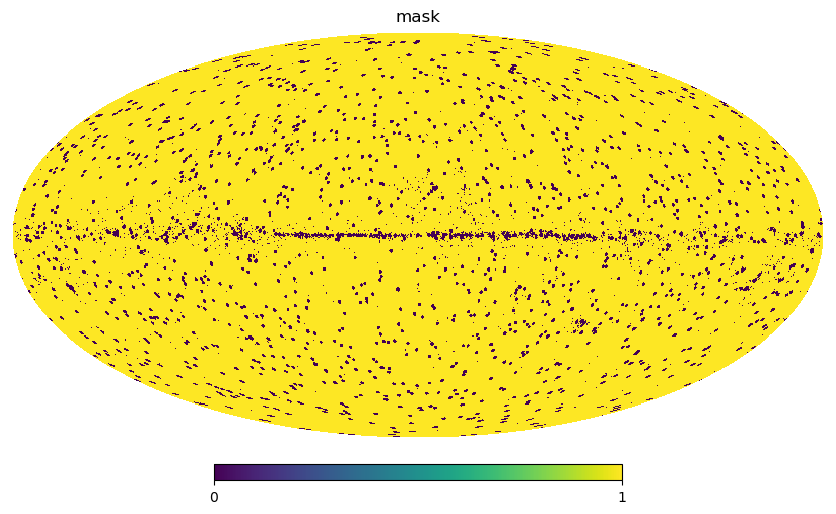

In [84]:
# Disable external TeX rendering
plt.rcParams.update({
    "text.usetex": False,
    "mathtext.fontset": "stix" # This still gives you nice, LaTeX-like math fonts
})

preprocessing_mask = HFImask*LFImask #hp

hp.mollview(preprocessing_mask,title='mask')
plt.show()

#car
#preprocessing_mask_planck = reproject.healpix2map(preprocessing_mask, imap.shape, imap.wcs, lmax=6000,rot='gal,equ') ###!!!FIX imap
#eshow(preprocessing_mask_planck, **{"downgrade": 2, "colorbar":True, "ticks": 10, })

findfont: Generic family 'serif' not found because none of the following families were found: cm10
findfont: Generic family 'serif' not found because none of the following families were found: cm10
findfont: Generic family 'serif' not found because none of the following families were found: cm10
findfont: Generic family 'serif' not found because none of the following families were found: cm10
findfont: Generic family 'serif' not found because none of the following families were found: cm10
findfont: Generic family 'serif' not found because none of the following families were found: cm10
findfont: Generic family 'serif' not found because none of the following families were found: cm10
findfont: Generic family 'serif' not found because none of the following families were found: cm10
findfont: Generic family 'serif' not found because none of the following families were found: cm10
findfont: Generic family 'serif' not found because none of the following families were found: cm10
findfont: 

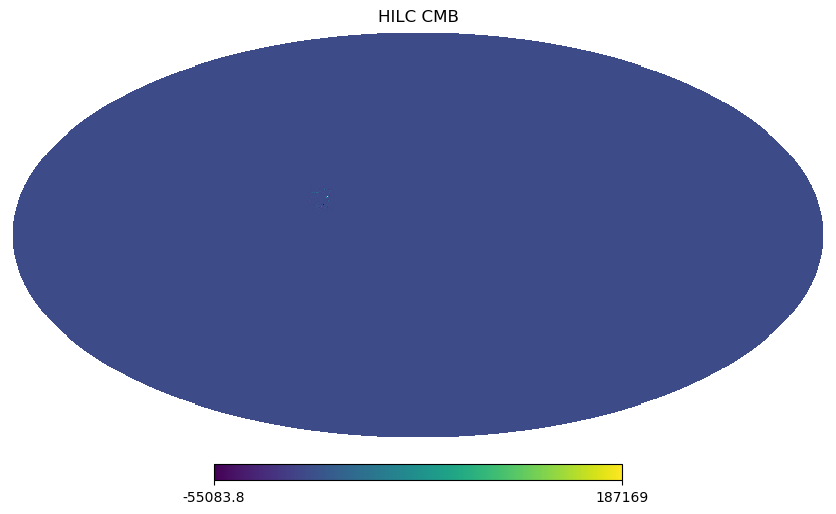

In [114]:
#hp.mollview(CMBmap_full ,title='HILC CMB') #hp
hp.mollview(preprocessing_mask*CMBmap_full,title='HILC CMB') #hp

plt.show()

#car
#eshow(preprocessing_mask_planck*CMBmap_full_planck, **{"downgrade": 2, "colorbar":True, "ticks": 10, })

Mean: -0.08140752319128541


findfont: Generic family 'serif' not found because none of the following families were found: cm10
findfont: Generic family 'serif' not found because none of the following families were found: cm10
findfont: Generic family 'serif' not found because none of the following families were found: cm10
findfont: Generic family 'serif' not found because none of the following families were found: cm10
findfont: Generic family 'serif' not found because none of the following families were found: cm10
findfont: Generic family 'serif' not found because none of the following families were found: cm10
findfont: Generic family 'serif' not found because none of the following families were found: cm10
findfont: Generic family 'serif' not found because none of the following families were found: cm10
findfont: Generic family 'serif' not found because none of the following families were found: cm10
findfont: Generic family 'serif' not found because none of the following families were found: cm10
findfont: 

Std Dev: 925.9564715518342
Max: 2945330.2128904224
Min: -2412148.2155207475


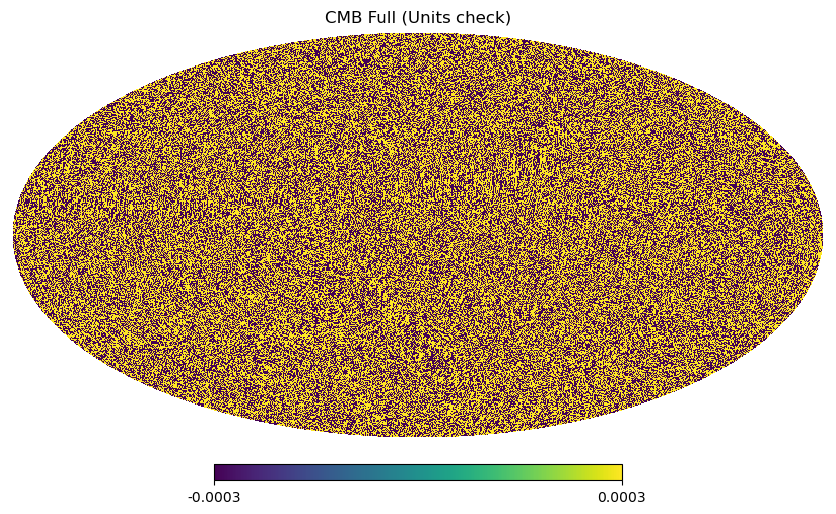

In [115]:
# Replace 'output_map' with whatever variable holds your ILC result
print(f"Mean: {np.mean(CMBmap_full)}")
print(f"Std Dev: {np.std(CMBmap_full)}")
print(f"Max: {np.max(CMBmap_full)}")
print(f"Min: {np.min(CMBmap_full)}")

# Try plotting with a restricted range (standard CMB is ~ +/- 300 uK)
hp.mollview(CMBmap_full, min=-0.0003, max=0.0003, title="CMB Full (Units check)")

In [122]:
# Check the stats of your input 90GHz map
test_map = hp.read_map('../data/healact_dr6.02_std_BR_night_pa4_f150_2way_set0_map.fits')
print(f"Input Map Max: {np.max(test_map)}")
print(f"Input Map Min: {np.min(test_map)}")

ValueError: Available hdu in [0-1]

In [39]:
old_car_map = enmap.read_map(datafolder+"cact_dr6.02_std_BR_night_pa4_f220_2way_set0_map.fits")
new_hp_map = reproject.map2healpix(old_car_map, nside = 4096, lmax = 8000)
hp.write_map("act_dr6.02_std_BR_night_pa4_f220_2way_set0_map.fits", new_hp_map, overwrite=True)

setting the output map dtype to [dtype('float32'), dtype('float32'), dtype('float32')]


In [ ]:
from astropy.io import fits

# Open an existing HEALPix FITS file
with fits.open(datafolder+"act_dr6.02_std_BR_night_pa5_f90_2way_set0_map.fits") as hdul:
    # Extension 1 usually contains the HEALPix metadata
    full_header = hdul[1].header
    
    # Slice the first 30 cards
    partial_header = full_header[:30]
    
    # To save these 30 lines to a new text file:
    with open("header_snippet_f090.txt", "w") as f:
        f.write(str(partial_header))


In [11]:
from astropy.io import fits

filepath = datafolder+'act_dr6.02_std_BR_night_pa4_f220_2way_set0_map.fits'

# Open the file in update mode
with fits.open(filepath, mode='update') as hdul:
    # Access the specific extension by name
    header = hdul['FREQ-MAP'].header
    
    # Update the BUNIT key
    header['BUNIT'] = 'uK_CMB'
    
    # The changes are flushed back to the file automatically when the context manager closes
    print(f"Updated BUNIT to: {header['BUNIT']}")

Updated BUNIT to: uK_CMB


In [95]:
from astropy.io import fits

filepath = datafolder+'kact_dr6.02_std_BR_night_pa5_f90_2way_set0_map.fits'
output_filename = datafolder+'act_dr6.02_std_BR_night_pa5_f90_2way_set0_map.fits'

# Open the file
with fits.open(filepath) as hdul:
    # Access the data and header of the 'FREQ-MAP' extension
    data = hdul['FREQ-MAP'].data
    header = hdul['FREQ-MAP'].header
    
    # 1. Perform the math: K to uK
    # This multiplies every pixel in the 3D cube by 1,000,000
    hdul['FREQ-MAP'].data = data * 1e-6
    
    # 2. Update the header to reflect the change
    header['BUNIT'] = 'K_CMB'
    
    # 3. Save as a new file (recommended over overwriting)
    hdul.writeto(output_filename, overwrite=True)

print(f"Conversion complete. File saved as {output_filename}")

Conversion complete. File saved as ../data/act_dr6.02_std_BR_night_pa5_f90_2way_set0_map.fits


What is the input? HEALPix or CAR? because it looks like pyilc's input.py can take both. 
If the given input is HEALPix, conversation can either be done before run_ilc_full or after.
(maybe we can analyze run time?)

For conversion HEALPix to CAR, figure out the shape&wcs parameters since at the moment they're reliant on nonexistent "imap." Also, figure out if I need "lmax" and "rot" or if they're inherited(?).

Figure out what the splits mean and if they are necessary.

Are we reading in Temperature, Polarization, or Lensing maps? (T, Q, U)